# Logistic Regression as a Single Neuron Model

## Imports

In [1]:
import numpy as np
import h5py
import requests
import os
import matplotlib.pyplot as plt

## Helper Functions (Just run this cell - no need to go through the code in helper functions)

In [2]:
def download_file(url, local_filename):
    """
    Downloads a file from a URL and saves it locally.
    """
    if not os.path.exists(local_filename):
        print(f"Downloading {local_filename}...")
        response = requests.get(url)
        if response.status_code == 200:
            with open(local_filename, 'wb') as f:
                f.write(response.content)
            print(f"File downloaded: {local_filename}")
        else:
            raise Exception(f"Failed to download file from {url}. Status code: {response.status_code}")
    else:
        print(f"File already exists: {local_filename}")

def load_dataset():
    # URLs of the .h5 files
    train_url = 'https://github.com/PyDataGBC/PyML2025/raw/refs/heads/main/LabWeek2/dataset/train_catvnoncat.h5'
    test_url = 'https://github.com/PyDataGBC/PyML2025/raw/refs/heads/main/LabWeek2/dataset/test_catvnoncat.h5'

    # Local file paths
    train_file = 'train_catvnoncat.h5'
    test_file = 'test_catvnoncat.h5'

    # Download the files if not already present
    download_file(train_url, train_file)
    download_file(test_url, test_file)

    # Open the files using h5py
    train_dataset = h5py.File(train_file, "r")
    train_set_x_orig = np.array(train_dataset["train_set_x"][:])  # Train set features
    train_set_y_orig = np.array(train_dataset["train_set_y"][:])  # Train set labels

    test_dataset = h5py.File(test_file, "r")
    test_set_x_orig = np.array(test_dataset["test_set_x"][:])  # Test set features
    test_set_y_orig = np.array(test_dataset["test_set_y"][:])  # Test set labels

    classes = np.array(test_dataset["list_classes"][:])  # List of classes

    # Reshape labels
    train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
    test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))

    return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes

## Importing Dataset

In [5]:
train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes = load_dataset()

File downloaded: train_catvnoncat.h5
File downloaded: test_catvnoncat.h5


## Data Visualization

label:  [1]


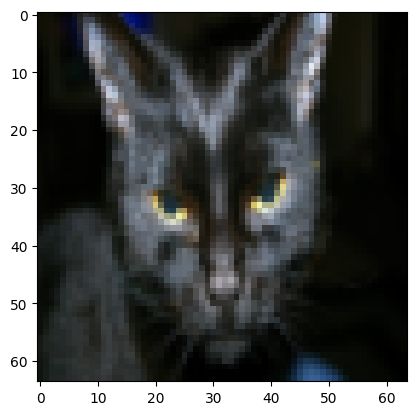

In [6]:
# Example of a picture
index = 25   # select a number between 0 and 208
#index = np.random.randint(0, 200)  # you can also generate a random number and see the different imagge each time
plt.imshow(train_set_x_orig[index])
print("label: ", train_set_y[:, index])

### **Exercise 1:** Take a look at five different images in train/test set. Try to see both cat and non-cat samples.

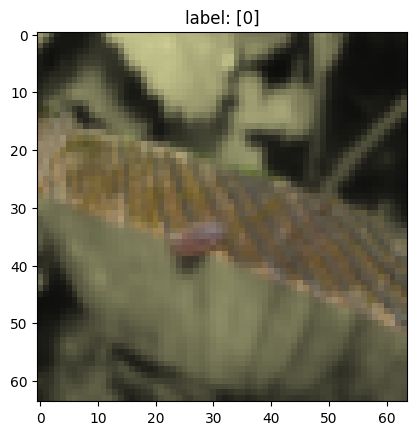

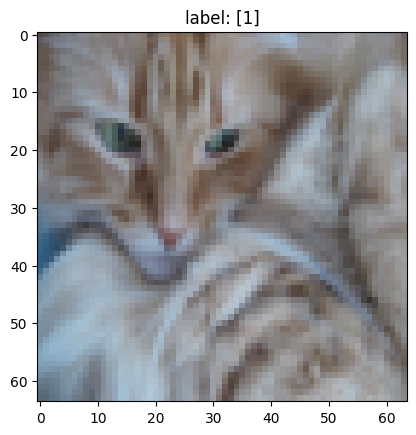

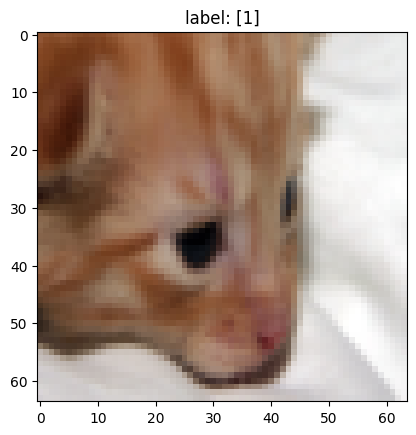

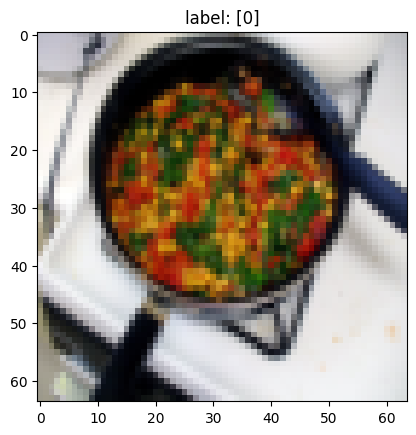

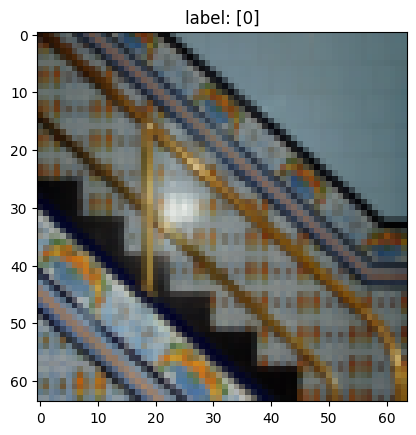

In [7]:
#your code here
# Visualize 5 random images from the train set
for i in range(5):
    index = np.random.randint(0, train_set_x_orig.shape[0])  # Random index for each image
    plt.imshow(train_set_x_orig[index])  # Show image
    plt.title(f"label: {train_set_y[:, index]}")
    plt.show()

### **Exercise 2:** Print `train_set_y` array to see the labels of the data. What percentage of the pictures in `train set` contain cats?

In [8]:
# your code here
# Print train_set_y to see the labels
print(train_set_y)

# Calculate the percentage of pictures containing cats
num_cats = np.sum(train_set_y == 1)  # Count how many cats (label 1)
num_total = train_set_y.shape[1]  # Total number of images in the train set
percentage_cats = (num_cats / num_total) * 100  # Calculate percentage
print(f"Percentage of images containing cats: {percentage_cats}%")


[[0 0 1 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0 1 1 0 1 0 1 0 0 0 0 0 0
  0 0 1 0 0 1 1 0 0 0 0 1 0 0 1 0 0 0 1 0 1 1 0 1 1 1 0 0 0 0 0 0 1 0 0 1
  0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 1 1 1 0 0 1 0 0 0 0 1 0 1 0 1 1
  1 1 1 1 0 0 0 0 0 1 0 0 0 1 0 0 1 0 1 0 1 1 0 0 0 1 1 1 1 1 0 0 0 0 1 0
  1 1 1 0 1 1 0 0 0 1 0 0 1 0 0 0 0 0 1 0 1 0 1 0 0 1 1 1 0 0 1 1 0 1 0 1
  0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0]]
Percentage of images containing cats: 34.44976076555024%


## Data Pre-processing

### Brief Theory: Numerical Representation of Images

![preprocessing](https://raw.githubusercontent.com/PyDataGBC/PyML2025/refs/heads/main/LabWeek2/assets/imvectorkiank.png)

### **Example 1:** Numerical Representation of an Image

![](https://raw.githubusercontent.com/PyDataGBC/PyML2025/refs/heads/main/LabWeek2/assets/imtovec_example.webp)

#### Step 1: Numerical representation of each channel (`MATRIX` format)

In [ ]:
red_channel = np.array([[255, 123, 135], [44, 12, 15], [56, 87, 90]]) # 2d array: Matrix
green_channel = np.array([[255, 133, 175], [24, 123, 169], [98, 66, 77]])
blue_channel = np.array([[66, 54, 88], [55, 98, 54], [87, 142, 89]])

print("Red Channel")
print(red_channel.shape)
print(red_channel)

print("Green Channel")
print(green_channel.shape)
print(green_channel)

print("Bue Channel")
print(blue_channel.shape)
print(blue_channel)



#### Step 2: Putting the channels together in the form of a `TENSOR`

In [ ]:
print("channel, height, width")
airplane_image = np.array([red_channel, green_channel, blue_channel])  # 3d array: Tensor
print(airplane_image.shape)
print(airplane_image)

#### Step 3: Flatten the `tensor` into a `VECTOR`

In [ ]:
airplane_flatten = airplane_image.flatten()   # 1d array: Vector
print(airplane_flatten.shape)
print(airplane_flatten)

### **Exercise 3:** Take one sample form train set again and check the shape of it. Try to interpret the numbers in the `shape`.

**Notes:**
- The images are 64x64 `pixels`.
- There are 3 RGB `channels`.

In [12]:
sample_index = 25
sample_image = train_set_x_orig[25]

#your code here
# Select one sample image
sample_index = 25
sample_image = train_set_x_orig[sample_index]

# Check the shape of the sample image
print(f"Shape of the sample image: {sample_image.shape}")


Shape of the sample image: (64, 64, 3)


### **Exercise 4:** Fallaten the this sample image? what is the size of the flattened image? why this number?

In [13]:
# Flatten the sample image
sample_image_flattened = sample_image.flatten()

# Check the size of the flattened image
print(f"Size of the flattened image: {sample_image_flattened.shape[0]}")


Size of the flattened image: 12288


### **Data Preprocessing:** Flattening the entrie Train and Test Datasets

**Note:** We're going to talk about the details of the following code in next sessions. For now just pay attentin to the output shapes of data.

In [ ]:
X_train = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1)
print("Train set shape: ", X_train.shape)

X_test = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1)
print("Test set shape: ", X_test.shape)

y_train = train_set_y[0]
print("Train label shape: ", y_train.shape)

y_test = test_set_y[0]
print("Test label shape: ", y_test.shape)



(209, 12288)
(50, 12288)
(209,)
(50,)


**Important Notes:**
- We have 209 samples in the train set, and
- 50 samples in the test set.
- each sample has 64x64x3=12288 `features`. So each pixel can be considered as one feature.
- remember that we had `4` features in `IRIS` dataset and now we have more than `10,000` features.

## Implementing Logistic Regression

This is what happens under the hood when you use the `LogisticRegression` classifier in scikit-learn.

![](https://raw.githubusercontent.com/PyDataGBC/PyML2025/refs/heads/main/LabWeek2/assets/LogReg_kiank.png)

### **Example 2:** What is the label in the following hypothetical input?

![](https://raw.githubusercontent.com/PyDataGBC/PyML2025/refs/heads/main/LabWeek2/assets/toyexample.png)

In [ ]:
#your calculation here


### **Exercise 6:** Train a `LogisticRegression` classifier to run a binary classification on the flattened cat pictures.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [15]:
#your code here
# Flatten the training and test sets
X_train = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1)  # Flattening the training set
X_test = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1)      # Flattening the test set

# Train the Logistic Regression classifier
clf = LogisticRegression(max_iter=1000)  # LogisticRegression model with 1000 iterations for convergence
clf.fit(X_train, train_set_y.T)           # Train the model using the training set and labels

# Predict using the trained classifier
y_pred_train = clf.predict(X_train)      # Predictions on the training set
y_pred_test = clf.predict(X_test)        # Predictions on the test set

# Calculate accuracy for both training and test sets
train_accuracy = accuracy_score(train_set_y.T, y_pred_train)
test_accuracy = accuracy_score(test_set_y.T, y_pred_test)

# Print the accuracy
print(f"Training accuracy: {train_accuracy}")
print(f"Test accuracy: {test_accuracy}")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Training accuracy: 1.0
Test accuracy: 0.66


### **Exercise 7:** Evaluate your model manually

1. Choose a random index of an image.
2. Display the image.
3. Print the original label.
4. Print the predicted label.
5. Repeat this process multiple times to identify which pictures are more challenging for the model.

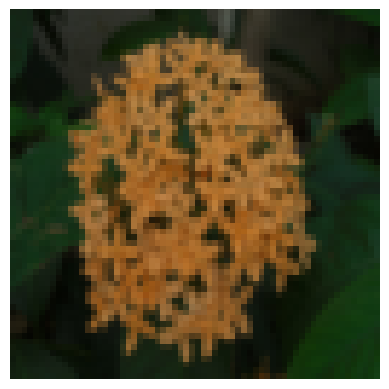

Original label: 0
Predicted label: 0


In [23]:
# Choose a random index
random_index = np.random.randint(0, X_test.shape[0])

# Display the image
plt.imshow(X_test[random_index].reshape(64, 64, 3))  # Reshape it back to 64x64x3 for display
plt.axis('off')
plt.show()

# Print the original label
print(f"Original label: {test_set_y[0, random_index]}")

# Print the predicted label
predicted_label = clf.predict(X_test[random_index].reshape(1, -1))  # Reshape to 1D array for prediction
print(f"Predicted label: {predicted_label[0]}")

### **Exercise 8:** Report the overall accuracy of your classifier

In [22]:
#you code here
# Calculate and print the overall accuracy on the test set
test_accuracy = accuracy_score(test_set_y.T, y_pred_test)
print(f"Overall test accuracy: {test_accuracy}")


Overall test accuracy: 0.66


## MNIST dataset (Exercise 9-12) - Optional, if you have extra time

In [17]:
#import mnist dataset
from keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [18]:
x_train.shape

(60000, 28, 28)

Label:  1
Image Shape:  (28, 28)


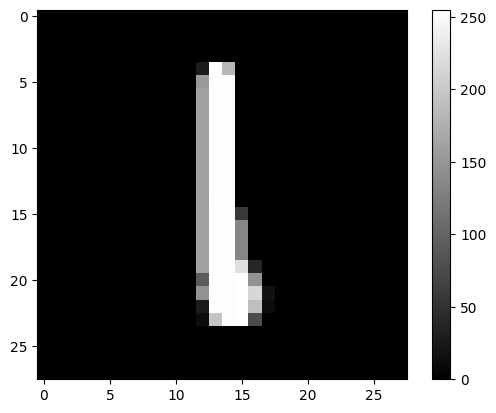

In [21]:
#Note: Run this cell multiple times
index = np.random.randint(0, x_train.shape[0])
print("Label: ", y_train[index])
print("Image Shape: ", x_train[index].shape)
plt.imshow(x_train[index], cmap='gray')
plt.colorbar()

### **Excercise 9:** What is the difference between a black-and-white image and a color image in terms of numerical representation?

### Hint: check the number of channels in the two types of images.

your answer here:

### **Exercise 10:** Select one data sample and flatten it. What is the size of the flattened image and why?

In [ ]:
## your code here

### **Excercise 11:** Flatten the images in Train and Test Datasets so that each image is a 1D array

In [ ]:
##your code here

### **Excercise 12:** Implement Logistic Regression on MNIST dataset using scikit-learn. What is the accuracy of your model?

In [ ]:
#your code here